   EXPLORATORY DATA ANALYSIS (EDA)
   Student Performance Dataset

[Raw] Shape       : (808, 13)
[Raw] Duplicates  : 8
[Raw] Missing     :
study_hours    15
sleep_hours    15
dtype: int64

[Clean] Final shape : (800, 13)
[Clean] Nulls left  : 0

── Statistical Summary ──
       study_hours  attendance_pct  sleep_hours  math_score  reading_score  \
count       800.00          800.00       800.00      800.00         800.00   
mean          5.21           79.42         6.82       68.10          70.84   
std           2.59           12.65         1.22       14.20          15.43   
min           0.50           36.50         3.00       28.60          23.90   
25%           3.40           71.97         6.00       58.00          60.80   
50%           4.80           81.55         6.80       67.60          70.80   
75%           6.60           89.20         7.60       78.12          81.82   
max          15.00           99.60        10.00      100.00         100.00   

       writing_score  ave

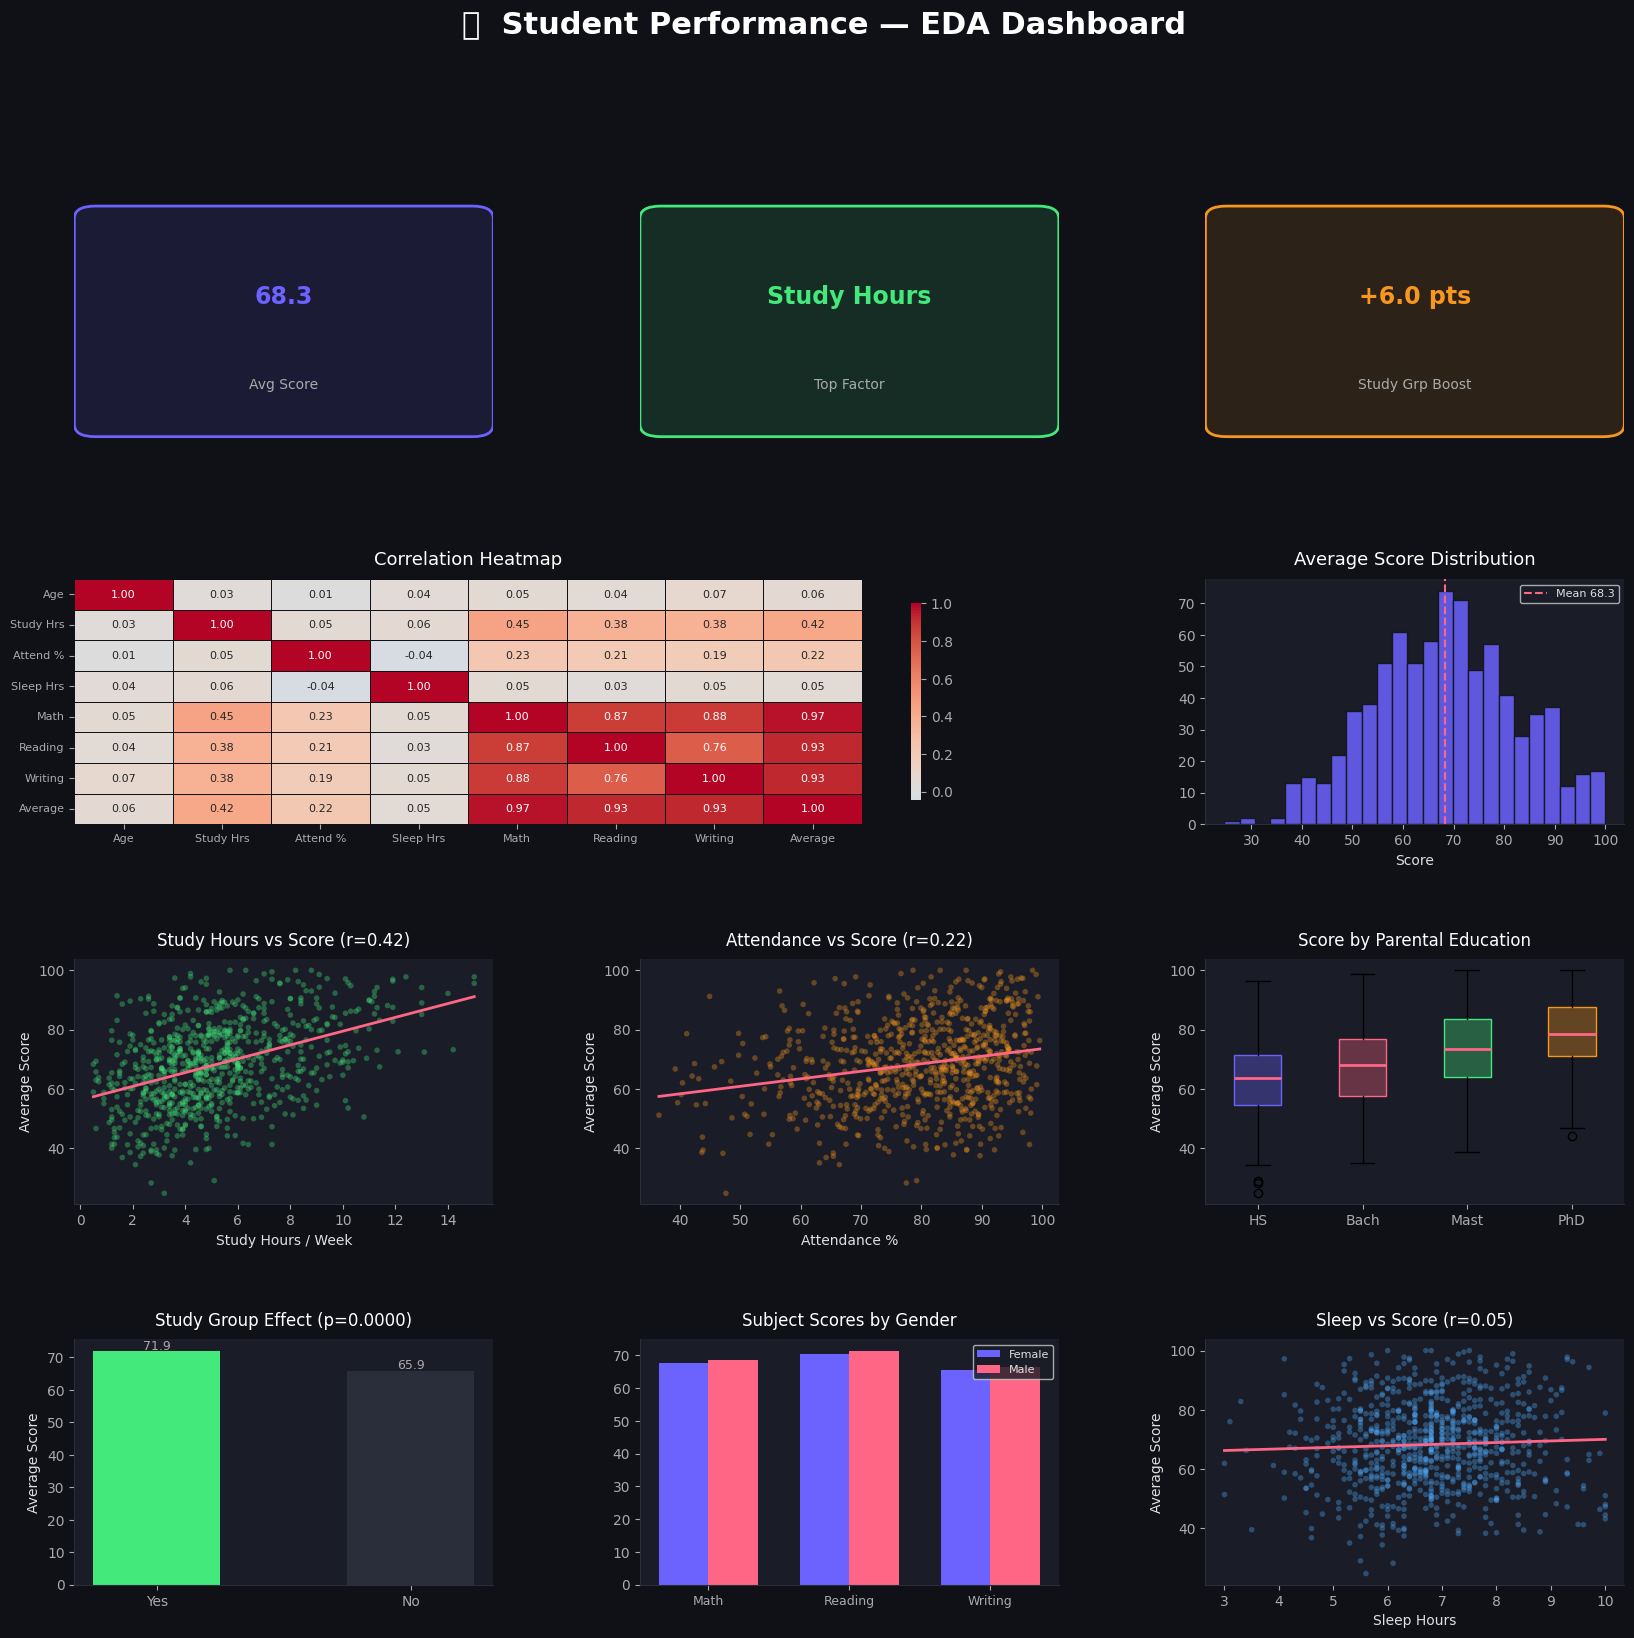

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("=" * 65)
print("   EXPLORATORY DATA ANALYSIS (EDA)")
print("   Student Performance Dataset")
print("=" * 65)

# ──────────────────────────────────────────────
# 1. GENERATE DATASET
# ──────────────────────────────────────────────
np.random.seed(42)
n = 800

genders        = ['Male', 'Female']
parent_edu     = ['High School', 'Bachelors', 'Masters', 'PhD']
lunch_types    = ['Standard', 'Free/Reduced']
study_groups   = ['Yes', 'No']
extracurr      = ['Yes', 'No']

gender          = np.random.choice(genders, n)
parental_edu    = np.random.choice(parent_edu, n, p=[0.35, 0.35, 0.2, 0.1])
lunch           = np.random.choice(lunch_types, n, p=[0.65, 0.35])
study_group     = np.random.choice(study_groups, n, p=[0.4, 0.6])
extracurricular = np.random.choice(extracurr, n, p=[0.45, 0.55])
study_hours     = np.random.gamma(4, 1.3, n).clip(0, 15).round(1)
attendance      = np.random.beta(8, 2, n) * 100
sleep_hours     = np.random.normal(6.8, 1.2, n).clip(3, 10).round(1)
age             = np.random.randint(15, 19, n)

# Score formula with realistic relationships + noise
edu_bonus  = {'High School': 0, 'Bachelors': 6, 'Masters': 11, 'PhD': 15}
lunch_bonus= {'Standard': 5, 'Free/Reduced': -3}
study_bonus= {'Yes': 4, 'No': 0}

base_score = (
    30
    + study_hours * 2.6
    + attendance * 0.22
    - np.abs(sleep_hours - 7.5) * 2.5     # too little/too much sleep both hurt
    + np.array([edu_bonus[e] for e in parental_edu])
    + np.array([lunch_bonus[l] for l in lunch])
    + np.array([study_bonus[s] for s in study_group])
    + np.random.normal(0, 10, n)
)

math_score    = base_score.clip(20, 100).round(1)
reading_score = (base_score + np.random.normal(3, 8, n)).clip(20, 100).round(1)
writing_score = (base_score + np.random.normal(-2, 8, n)).clip(20, 100).round(1)

df = pd.DataFrame({
    'gender'           : gender,
    'age'              : age,
    'parental_education': parental_edu,
    'lunch'            : lunch,
    'study_group'      : study_group,
    'extracurricular'  : extracurricular,
    'study_hours'      : study_hours,
    'attendance_pct'   : attendance.round(1),
    'sleep_hours'      : sleep_hours,
    'math_score'       : math_score,
    'reading_score'    : reading_score,
    'writing_score'    : writing_score,
})
df['average_score'] = df[['math_score','reading_score','writing_score']].mean(axis=1).round(1)

# Inject a few missing values and duplicates for realism
for col in ['study_hours', 'sleep_hours']:
    idx = np.random.choice(df.index, size=15, replace=False)
    df.loc[idx, col] = np.nan
df = pd.concat([df, df.sample(8, random_state=1)], ignore_index=True)

print(f"\n[Raw] Shape       : {df.shape}")
print(f"[Raw] Duplicates  : {df.duplicated().sum()}")
print(f"[Raw] Missing     :\n{df.isnull().sum()[df.isnull().sum() > 0]}")

# ──────────────────────────────────────────────
# 2. CLEANING
# ──────────────────────────────────────────────
df = df.drop_duplicates().reset_index(drop=True)
df['study_hours'] = df['study_hours'].fillna(df['study_hours'].median())
df['sleep_hours'] = df['sleep_hours'].fillna(df['sleep_hours'].median())
print(f"\n[Clean] Final shape : {df.shape}")
print(f"[Clean] Nulls left  : {df.isnull().sum().sum()}")

# ──────────────────────────────────────────────
# 3. STATISTICAL SUMMARY
# ──────────────────────────────────────────────
print("\n── Statistical Summary ──")
print(df[['study_hours','attendance_pct','sleep_hours',
          'math_score','reading_score','writing_score','average_score']].describe().round(2))

# ──────────────────────────────────────────────
# 4. CORRELATION ANALYSIS
# ──────────────────────────────────────────────
numeric_cols = ['age','study_hours','attendance_pct','sleep_hours',
                'math_score','reading_score','writing_score','average_score']
corr = df[numeric_cols].corr()

print("\n── Correlation with Average Score ──")
score_corr = corr['average_score'].drop('average_score').sort_values(ascending=False)
print(score_corr.round(3))

behavioral_factors = ['study_hours','attendance_pct','sleep_hours','age']
behavioral_corr = score_corr[behavioral_factors].sort_values(ascending=False)
print("\n── Behavioral/Demographic Correlation with Average Score ──")
print(behavioral_corr.round(3))

# Statistical test: study group vs average score (t-test)
grp_yes = df[df['study_group']=='Yes']['average_score']
grp_no  = df[df['study_group']=='No']['average_score']
t_stat, p_val = stats.ttest_ind(grp_yes, grp_no)
print(f"\n[T-test] Study Group Yes vs No → t={t_stat:.2f}, p={p_val:.5f}")
print(f"  {'Statistically significant' if p_val < 0.05 else 'Not statistically significant'} difference (α=0.05)")

# ──────────────────────────────────────────────
# 5. KEY INSIGHTS
# ──────────────────────────────────────────────
top_factor   = behavioral_corr.index[0]
top_corr_val = behavioral_corr.iloc[0]
study_diff   = grp_yes.mean() - grp_no.mean()
gender_gap   = df.groupby('gender')['average_score'].mean()
edu_impact   = df.groupby('parental_education')['average_score'].mean().sort_values(ascending=False)

print(f"\n── Key Insights ──")
print(f"  Strongest correlate of score : {top_factor} (r={top_corr_val:.3f})")
print(f"  Study group score boost      : +{study_diff:.1f} points")
print(f"  Gender score gap             : {abs(gender_gap.diff().iloc[-1]):.1f} points")
print(f"  Top parental education group : {edu_impact.index[0]} ({edu_impact.iloc[0]:.1f} avg)")

# ──────────────────────────────────────────────
# 6. EDA DASHBOARD
# ──────────────────────────────────────────────
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#1a1d27',
    'text.color'       : '#e0e0e0',
    'axes.labelcolor'  : '#e0e0e0',
    'xtick.color'      : '#aaaaaa',
    'ytick.color'      : '#aaaaaa',
    'axes.edgecolor'   : '#2a2d3a',
    'grid.color'       : '#2a2d3a',
    'grid.linewidth'   : 0.5,
})

PALETTE = ['#6c63ff','#ff6584','#43e97b','#f7971e','#4facfe']
ACCENT  = '#6c63ff'

fig = plt.figure(figsize=(20, 18), facecolor='#0f1117')
fig.suptitle('🎓  Student Performance — EDA Dashboard',
             fontsize=22, fontweight='bold', color='white', y=0.985)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.35)

# ── KPI cards ──
kpis = [
    ("Avg Score",       f"{df['average_score'].mean():.1f}",        '#6c63ff'),
    ("Top Factor",       top_factor.replace('_',' ').title(),       '#43e97b'),
    ("Study Grp Boost",  f"+{study_diff:.1f} pts",                  '#f7971e'),
]
for i, (label, val, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor('#1a1d27'); ax.axis('off')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    rect = FancyBboxPatch((0.05,0.08), 0.9, 0.84,
                          boxstyle="round,pad=0.05",
                          facecolor=color+'22', edgecolor=color, linewidth=2)
    ax.add_patch(rect)
    ax.text(0.5, 0.60, val,   ha='center', va='center',
            fontsize=17, fontweight='bold', color=color)
    ax.text(0.5, 0.24, label, ha='center', va='center',
            fontsize=10, color='#aaaaaa')

# ── Correlation Heatmap ──
ax1 = fig.add_subplot(gs[1, :2])
mask_labels = ['Age','Study Hrs','Attend %','Sleep Hrs','Math','Reading','Writing','Average']
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax1, cbar_kws={'shrink':0.8}, linewidths=0.5,
            linecolor='#0f1117', xticklabels=mask_labels, yticklabels=mask_labels,
            annot_kws={'fontsize':8})
ax1.set_title('Correlation Heatmap', color='white', fontsize=13, pad=10)
ax1.tick_params(labelsize=8)

# ── Score Distribution ──
ax2 = fig.add_subplot(gs[1, 2])
ax2.hist(df['average_score'], bins=25, color=ACCENT, alpha=0.85, edgecolor='#0f1117')
ax2.axvline(df['average_score'].mean(), color='#ff6584', linestyle='--', linewidth=1.5,
            label=f"Mean {df['average_score'].mean():.1f}")
ax2.set_title('Average Score Distribution', color='white', fontsize=13, pad=10)
ax2.set_xlabel('Score')
ax2.legend(fontsize=8)

# ── Study Hours vs Score (scatter + trend) ──
ax3 = fig.add_subplot(gs[2, 0])
ax3.scatter(df['study_hours'], df['average_score'], alpha=0.35, s=16,
            color='#43e97b', edgecolors='none')
z = np.polyfit(df['study_hours'], df['average_score'], 1)
xline = np.linspace(df['study_hours'].min(), df['study_hours'].max(), 50)
ax3.plot(xline, np.poly1d(z)(xline), color='#ff6584', linewidth=2)
ax3.set_xlabel('Study Hours / Week')
ax3.set_ylabel('Average Score')
ax3.set_title(f'Study Hours vs Score (r={score_corr.get("study_hours",0):.2f})',
              color='white', fontsize=12, pad=10)

# ── Attendance vs Score ──
ax4 = fig.add_subplot(gs[2, 1])
ax4.scatter(df['attendance_pct'], df['average_score'], alpha=0.35, s=16,
            color='#f7971e', edgecolors='none')
z2 = np.polyfit(df['attendance_pct'], df['average_score'], 1)
xline2 = np.linspace(df['attendance_pct'].min(), df['attendance_pct'].max(), 50)
ax4.plot(xline2, np.poly1d(z2)(xline2), color='#ff6584', linewidth=2)
ax4.set_xlabel('Attendance %')
ax4.set_ylabel('Average Score')
ax4.set_title(f'Attendance vs Score (r={score_corr.get("attendance_pct",0):.2f})',
              color='white', fontsize=12, pad=10)

# ── Score by Parental Education ──
ax5 = fig.add_subplot(gs[2, 2])
edu_order = ['High School','Bachelors','Masters','PhD']
edu_data  = [df[df['parental_education']==e]['average_score'] for e in edu_order]
bp = ax5.boxplot(edu_data, labels=['HS','Bach','Mast','PhD'], patch_artist=True,
                 medianprops=dict(color='#ff6584', linewidth=2))
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color+'55'); patch.set_edgecolor(color)
ax5.set_title('Score by Parental Education', color='white', fontsize=12, pad=10)
ax5.set_ylabel('Average Score')

# ── Study Group Comparison ──
ax6 = fig.add_subplot(gs[3, 0])
sg_means = df.groupby('study_group')['average_score'].mean().reindex(['Yes','No'])
bar_colors_sg = ['#43e97b' if g == 'Yes' else '#2a2d3a' for g in sg_means.index]
bars = ax6.bar(sg_means.index, sg_means.values, color=bar_colors_sg, width=0.5)
ax6.set_title(f'Study Group Effect (p={p_val:.4f})', color='white', fontsize=12, pad=10)
ax6.set_ylabel('Average Score')
for bar, val in zip(bars, sg_means.values):
    ax6.text(bar.get_x()+bar.get_width()/2, val+0.5, f'{val:.1f}',
             ha='center', fontsize=9, color='#aaaaaa')

# ── Gender Comparison ──
ax7 = fig.add_subplot(gs[3, 1])
gen_means = df.groupby('gender')[['math_score','reading_score','writing_score']].mean()
x = np.arange(len(gen_means.columns))
width = 0.35
for i, (gen, color) in enumerate(zip(gen_means.index, ['#6c63ff','#ff6584'])):
    ax7.bar(x + i*width, gen_means.loc[gen], width, label=gen, color=color)
ax7.set_xticks(x + width/2)
ax7.set_xticklabels(['Math','Reading','Writing'], fontsize=9)
ax7.set_title('Subject Scores by Gender', color='white', fontsize=12, pad=10)
ax7.legend(fontsize=8)

# ── Sleep Hours vs Score ──
ax8 = fig.add_subplot(gs[3, 2])
ax8.scatter(df['sleep_hours'], df['average_score'], alpha=0.35, s=16,
            color='#4facfe', edgecolors='none')
z3 = np.polyfit(df['sleep_hours'], df['average_score'], 1)
xline3 = np.linspace(df['sleep_hours'].min(), df['sleep_hours'].max(), 50)
ax8.plot(xline3, np.poly1d(z3)(xline3), color='#ff6584', linewidth=2)
ax8.set_xlabel('Sleep Hours')
ax8.set_ylabel('Average Score')
ax8.set_title(f'Sleep vs Score (r={score_corr.get("sleep_hours",0):.2f})',
              color='white', fontsize=12, pad=10)

plt.savefig('student_eda_dashboard.png',
            dpi=160, bbox_inches='tight', facecolor='#0f1117')
print("\n✅ Dashboard saved → student_eda_dashboard.png")

# ──────────────────────────────────────────────
# 7. SAVE OUTPUTS
# ──────────────────────────────────────────────
df.to_csv('student_performance_dataset.csv', index=False)
corr.to_csv('correlation_matrix.csv')
print("✅ Dataset   saved → student_performance_dataset.csv")
print("✅ Correlation matrix saved → correlation_matrix.csv")
print("\nDone! 🎉")